In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

## Step 1: Import Libraries

Imported the required libraries for data handling, visualization, machine learning, and model evaluation.

In [3]:
housing = fetch_california_housing()

In [4]:
df = pd.DataFrame(
    housing.data,
    columns = housing.feature_names
)   

In [5]:
df["Price"] = housing.target

In [6]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [8]:
df.shape

(20640, 9)

## Step 2: Load Dataset

Loaded the California Housing dataset and converted it into a pandas DataFrame. Added the target column (Price) for regression.

In [9]:
df.head() 

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Step 3: Explore Dataset

Explored the dataset to understand its structure, features, and summary statistics before building the machine learning model.

In [12]:
X= df.drop("Price",axis=1)
y= df["Price"]

In [13]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [14]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

## Step 4: Select Features and Target

Separated the dataset into input features (X) and the target variable (Price). The model will use the features to predict house prices.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


## Step 5: Split the Dataset

Split the dataset into training and testing sets. The model learns from the training data and is evaluated on unseen testing data.

In [17]:
model = LinearRegression()

## Step 6: Create the Model

Created a Linear Regression model that will learn the relationship between house features and house prices.

In [18]:
model.fit(X_train,y_train)

LinearRegression()

## Step 7: Train the Model

Trained the Linear Regression model using the training dataset. The model learned the relationship between the input features and house prices.

In [19]:
y_pred = model.predict(X_test)

In [20]:
print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [21]:
print(y_test[:10].values)

[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


## Step 8: Make Predictions

Used the trained Linear Regression model to predict house prices for the testing dataset.

In [22]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 0.7455813830127761


### Observation

The RMSE of the model is approximately **0.75**, which means the predicted house prices are, on average, about **0.75 units** away from the actual prices. A lower RMSE indicates better prediction accuracy.

## RMSE

Calculated the Root Mean Squared Error (RMSE), which measures the average prediction error. A lower RMSE indicates better model performance.

In [23]:
r2 = r2_score(y_test,y_pred)
print("R² Score:", r2)

R² Score: 0.5757877060324511


### R² Score Explanation

The R² score of my model is **0.576**. This means the model explains about **57.6%** of the variation in house prices using the selected features. While the model captures a good portion of the relationship, there are still other factors affecting house prices that were not included in the dataset. Overall, this is a reasonable result for a basic Linear Regression model.

## R² Score

Calculated the R² Score to measure how well the model explains the variation in house prices. A value closer to 1 indicates better performance.

### What does the R² Score mean?

The R² score tells us how well the model predicts house prices. A value closer to 1 means the model explains most of the changes in house prices, while a value closer to 0 means the model does not predict prices very well.

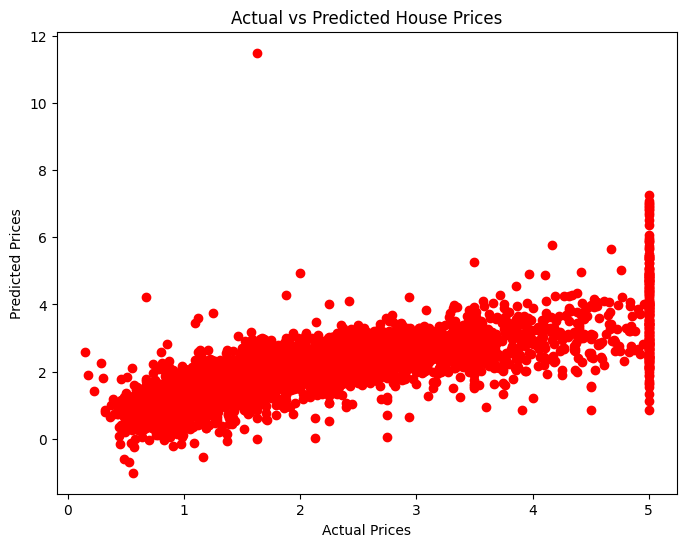

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color="red")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

## Step 10: Scatter Plot

Created a scatter plot to compare actual house prices with predicted house prices. Points closer to a straight diagonal pattern indicate better model performance.

### Observation:

The scatter plot shows a positive relationship between the actual and predicted house prices. Most data points follow an upward trend, which indicates that the model is able to predict house prices reasonably well. However, some points are scattered away from the main pattern, showing that the model makes larger prediction errors for a few houses.

# Conclusion

Successfully built a Linear Regression model to predict house prices using the California Housing dataset.

The dataset was divided into training and testing sets, and the model learned the relationship between house features and house prices.

The model's performance was evaluated using RMSE and R² Score. Finally, a scatter plot was created to compare actual and predicted prices.